# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [7]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/ethanjia/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [8]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [9]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32)
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32)

    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("num_features:", num_features)
print("num_classes:", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)
num_features: 561
num_classes: 6


## 4. Quick Inspection

In [10]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

class_counts = np.bincount(y_train, minlength=num_classes)

summary_df = pd.DataFrame({
    "class index": np.arange(num_classes),
    "class name": class_names,
    "number of training samples": class_counts
})

summary_df

,class index,class name,number of training samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [11]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1398 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1150 - accuracy: 0.9572 - val_loss: 0.2550 - val_accuracy: 0.9164
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0916 - accuracy: 0.9636 - val_loss: 0.1449 - val_accuracy: 0.9422
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0873 - accuracy: 0.9657 - val_loss: 0.2036 - val_accuracy: 0.9259
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0743 - accuracy: 0.9696 - val_loss: 0.1790 - val_accuracy: 0.9388
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0662 - accuracy: 0.9747 - val_loss: 0.1292 - val_accuracy: 0.9483
Epoch 8/40
92/92 [==

### Training Curves

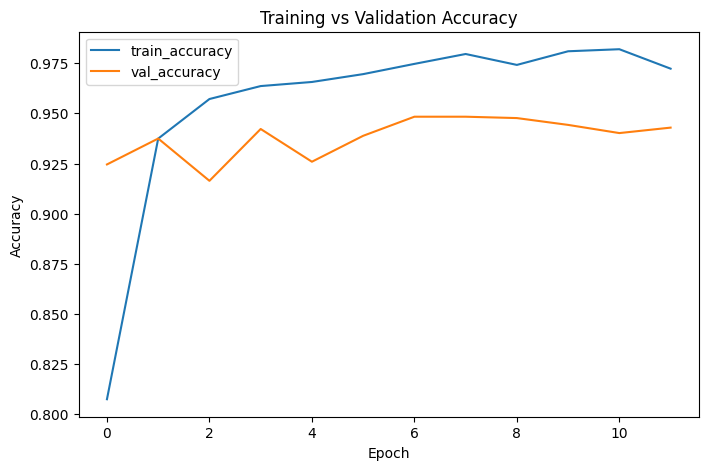

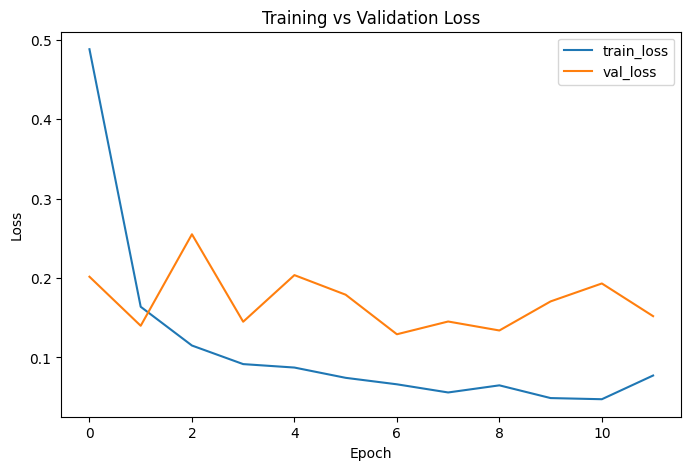

In [13]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 784us/step
Test Accuracy: 0.9331523583305056
                    precision    recall  f1-score   support

           WALKING       0.96      0.98      0.97       496
  WALKING_UPSTAIRS       0.86      0.97      0.92       471
WALKING_DOWNSTAIRS       0.99      0.83      0.90       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.88      0.95      0.91       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



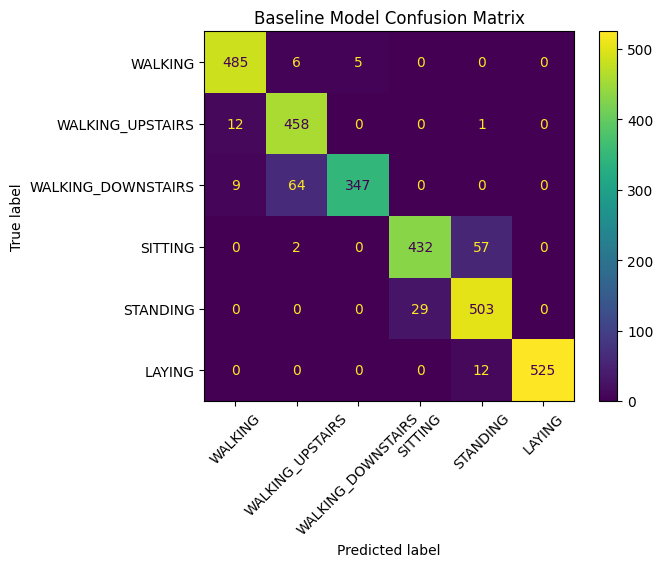

In [14]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_acc)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Baseline Model Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [15]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [16]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

baseline_tflite = convert_to_tflite_fp32(baseline_model)
baseline_tflite_size_kb = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_tflite_acc, baseline_tflite_pred = evaluate_tflite_model(baseline_tflite, X_test, y_test)

print("Baseline FP32 TFLite size (KB):", baseline_tflite_size_kb)
print("Baseline FP32 TFLite test accuracy:", baseline_tflite_acc)


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpchh4ywtp/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpchh4ywtp/assets


Baseline FP32 TFLite size (KB): 726.71875
Baseline FP32 TFLite test accuracy: 0.9331523583305056


2026-04-22 18:43:52.107922: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:43:52.107931: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:43:52.108086: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpchh4ywtp
2026-04-22 18:43:52.108559: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:43:52.108563: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpchh4ywtp
2026-04-22 18:43:52.109430: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-22 18:43:52.109794: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:43:52.129774: I tensorflow/cc/saved_model/loader.

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [17]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

pruned_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1662 - accuracy: 0.9367 - val_loss: 0.1591 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1314 - accuracy: 0.9493 - val_loss: 0.2293 - val_accuracy: 0.9252
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0901 - accuracy: 0.9699 - val_loss: 0.1750 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1388 - accuracy: 0.9476 - val_loss: 0.1383 - val_accuracy: 0.9415
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1209 - accuracy: 0.9607 - val_loss: 0.1783 - val_accuracy: 0.9347
Epoch 7/12
92/92 [==============================] - 0s 2ms/step - loss: 0.3121 - accuracy: 0.9255 - val_loss: 0.1751 - val_accuracy: 0.9334
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [18]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

pruned_tflite = convert_to_tflite_fp32(pruned_model)
pruned_tflite_size_kb = save_binary_model(pruned_tflite, "pruned_fp32_with_mask.tflite")
pruned_tflite_acc, pruned_tflite_pred = evaluate_tflite_model(pruned_tflite, X_test, y_test)

stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_tflite_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_tflite_acc, stripped_sparse_tflite_pred = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print("Pruned FP32 TFLite with mask size (KB):", pruned_tflite_size_kb)
print("Pruned FP32 TFLite with mask accuracy:", pruned_tflite_acc)
print("Stripped sparse FP32 TFLite size (KB):", stripped_sparse_tflite_size_kb)
print("Stripped sparse FP32 TFLite accuracy:", stripped_sparse_tflite_acc)


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpe9q2anyb/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpe9q2anyb/assets
2026-04-22 18:43:55.716021: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:43:55.716032: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:43:55.716126: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpe9q2anyb
2026-04-22 18:43:55.717696: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:43:55.717701: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpe9q2anyb
2026-04-22 18:43:55.721529: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:43:55.749603: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpgzw0yg3v/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpgzw0yg3v/assets
2026-04-22 18:43:56.390356: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:43:56.390367: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned FP32 TFLite with mask size (KB): 1454.17578125
Pruned FP32 TFLite with mask accuracy: 0.9375636240244316
Stripped sparse FP32 TFLite size (KB): 162.9921875
Stripped sparse FP32 TFLite accuracy: 0.9375636240244316


2026-04-22 18:43:56.390459: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpgzw0yg3v
2026-04-22 18:43:56.390762: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:43:56.390765: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpgzw0yg3v
2026-04-22 18:43:56.391452: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:43:56.399625: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpgzw0yg3v
2026-04-22 18:43:56.402556: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 12097 microseconds.


## 11. Part I Comparison: Accuracy and Model Size

In [19]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Pruned",
        "Stripped Sparse"
    ],
    "Format": [
        "FP32 TFLite",
        "FP32 TFLite with mask",
        "Sparse FP32 TFLite"
    ],
    "Test Accuracy": [
        baseline_tflite_acc,
        pruned_tflite_acc,
        stripped_sparse_tflite_acc
    ],
    "Model Size (KB)": [
        baseline_tflite_size_kb,
        pruned_tflite_size_kb,
        stripped_sparse_tflite_size_kb
    ]
})

part1_df


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.933152,726.718750
1,Pruned,FP32 TFLite with mask,0.937564,1454.175781
2,Stripped Sparse,Sparse FP32 TFLite,0.937564,162.992188


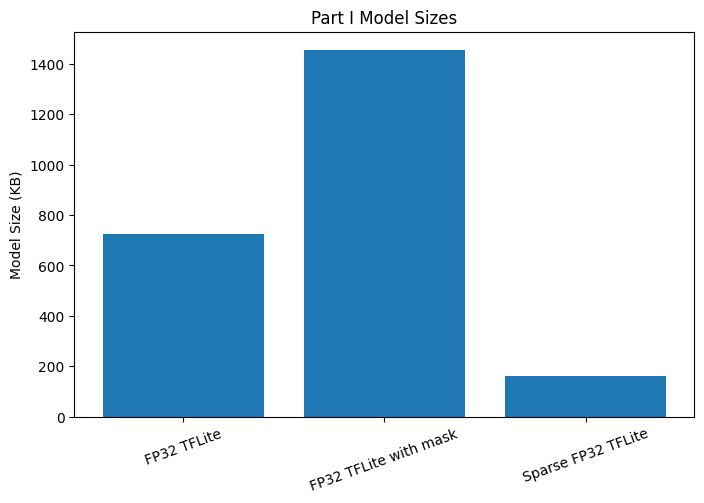

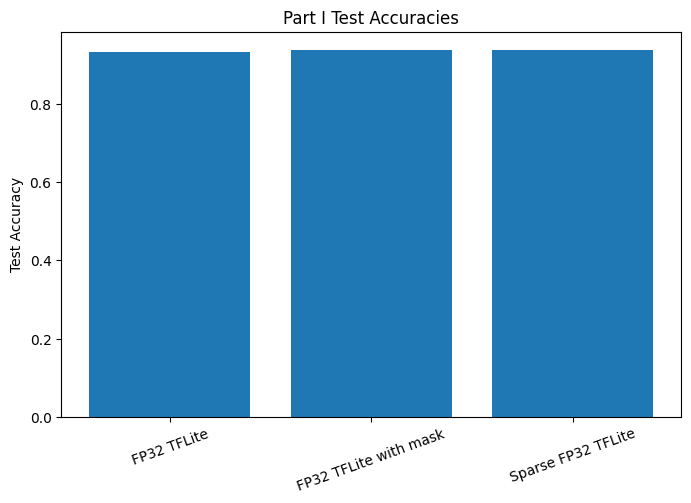

In [20]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

plt.figure(figsize=(8, 5))
plt.bar(part1_df["Format"], part1_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Part I Model Sizes")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(part1_df["Format"], part1_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Part I Test Accuracies")
plt.xticks(rotation=20)
plt.show()


### Confusion Matrix for the Stripped Sparse Model

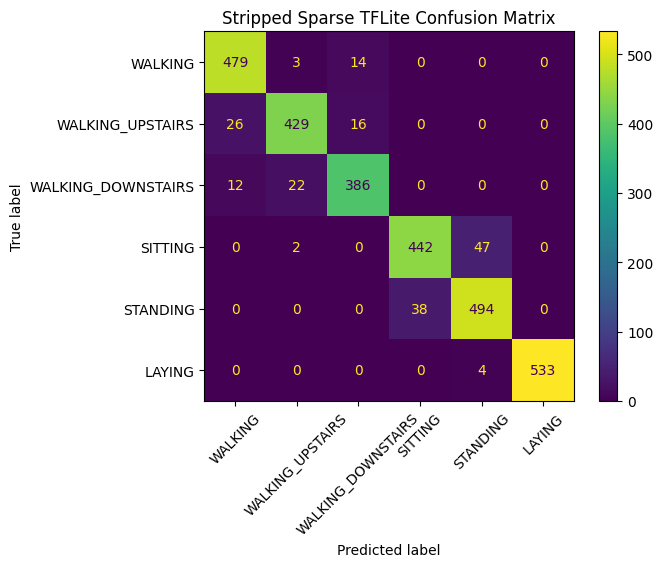

                    precision    recall  f1-score   support

           WALKING       0.93      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.91      0.93       471
WALKING_DOWNSTAIRS       0.93      0.92      0.92       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [21]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

cm = confusion_matrix(y_test, stripped_sparse_tflite_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Stripped Sparse TFLite Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_tflite_pred, target_names=class_names))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [22]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_float16_tflite = converter.convert()

pruned_float16_tflite_size_kb = save_binary_model(pruned_float16_tflite, "pruned_float16_with_mask.tflite")
pruned_float16_tflite_acc, pruned_float16_tflite_pred = evaluate_tflite_model(pruned_float16_tflite, X_test, y_test)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()

stripped_sparse_float16_tflite_size_kb = save_binary_model(stripped_sparse_float16_tflite, "stripped_sparse_float16.tflite")
stripped_sparse_float16_tflite_acc, stripped_sparse_float16_tflite_pred = evaluate_tflite_model(
    stripped_sparse_float16_tflite, X_test, y_test
)

print("Pruned float16 TFLite with mask size (KB):", pruned_float16_tflite_size_kb)
print("Pruned float16 TFLite with mask accuracy:", pruned_float16_tflite_acc)
print("Stripped sparse float16 TFLite size (KB):", stripped_sparse_float16_tflite_size_kb)
print("Stripped sparse float16 TFLite accuracy:", stripped_sparse_float16_tflite_acc)


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpqa0hp04k/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpqa0hp04k/assets
2026-04-22 18:43:57.439673: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:43:57.439683: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:43:57.439779: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpqa0hp04k
2026-04-22 18:43:57.441472: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:43:57.441481: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmpqa0hp04k
2026-04-22 18:43:57.445789: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:43:57.474464: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp8dz0pll5/assets


INFO:tensorflow:Assets written to: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp8dz0pll5/assets


Pruned float16 TFLite with mask size (KB): 732.5859375
Pruned float16 TFLite with mask accuracy: 0.9375636240244316
Stripped sparse float16 TFLite size (KB): 108.7421875
Stripped sparse float16 TFLite accuracy: 0.9375636240244316


2026-04-22 18:43:57.979913: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:43:57.979923: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:43:57.980013: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp8dz0pll5
2026-04-22 18:43:57.980417: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:43:57.980420: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp8dz0pll5
2026-04-22 18:43:57.981189: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:43:57.989405: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/h8/_8jg9xyj0b1fv064kh64kr300000gn/T/tmp8dz0pll5
2026-04-

## 12. Part II Comparison: Accuracy and Model Size

In [23]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

part2_df = pd.DataFrame({
    "Model": [
        "Pruned",
        "Stripped Sparse",
        "Pruned",
        "Stripped Sparse"
    ],
    "Format": [
        "FP32 with mask",
        "Sparse FP32",
        "Float16 with mask",
        "Sparse Float16"
    ],
    "Test Accuracy": [
        pruned_tflite_acc,
        stripped_sparse_tflite_acc,
        pruned_float16_tflite_acc,
        stripped_sparse_float16_tflite_acc
    ],
    "Model Size (KB)": [
        pruned_tflite_size_kb,
        stripped_sparse_tflite_size_kb,
        pruned_float16_tflite_size_kb,
        stripped_sparse_float16_tflite_size_kb
    ]
})

part2_df


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned,FP32 with mask,0.937564,1454.175781
1,Stripped Sparse,Sparse FP32,0.937564,162.992188
2,Pruned,Float16 with mask,0.937564,732.585938
3,Stripped Sparse,Sparse Float16,0.937564,108.742188


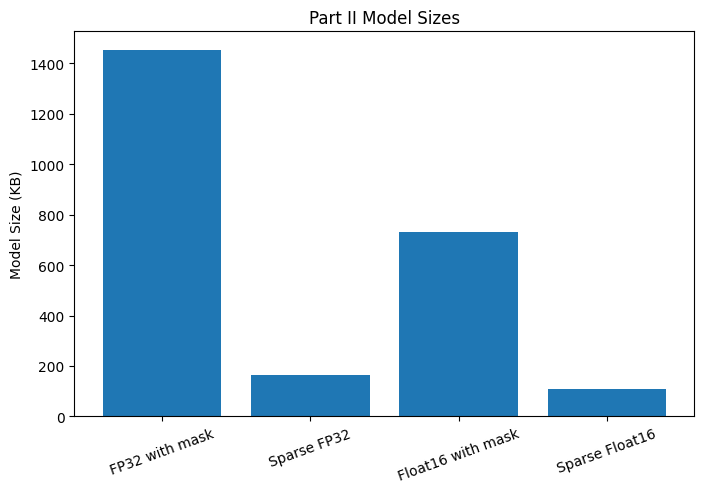

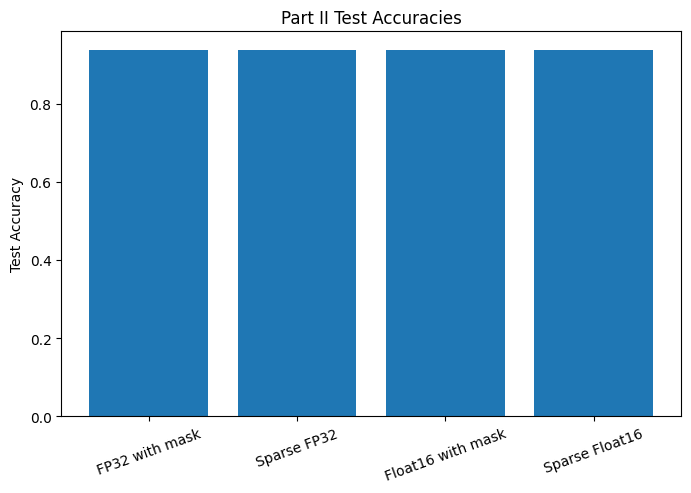

In [24]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

plt.figure(figsize=(8, 5))
plt.bar(part2_df["Format"], part2_df["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Part II Model Sizes")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(part2_df["Format"], part2_df["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Part II Test Accuracies")
plt.xticks(rotation=20)
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

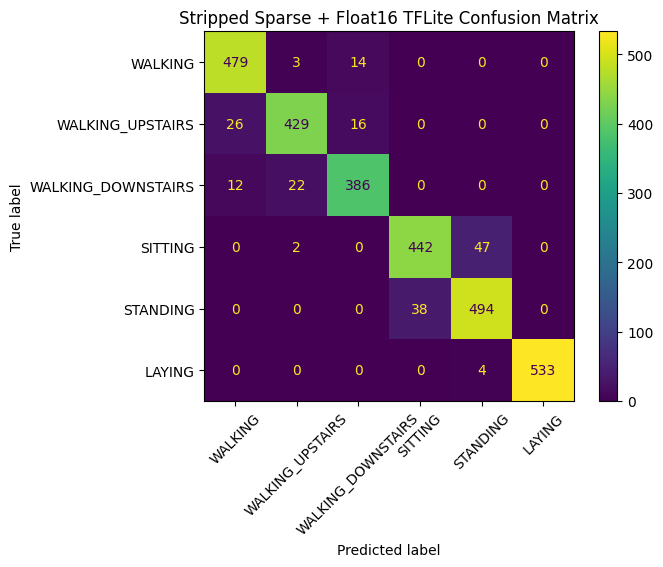

                    precision    recall  f1-score   support

           WALKING       0.93      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.91      0.93       471
WALKING_DOWNSTAIRS       0.93      0.92      0.92       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [25]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

cm = confusion_matrix(y_test, stripped_sparse_float16_tflite_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Stripped Sparse + Float16 TFLite Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_float16_tflite_pred, target_names=class_names))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. No. Pruning alone did not significantly reduce the TensorFlow Lite file size while the pruning wrappers were still attached.
2. strip_pruning(...) matters because it removes the pruning wrappers and extra training-only metadata, leaving a smaller exportable model.
3. The fully quantized int8 model had the smallest file size in this notebook.
4. No. Float16 quantization did not noticeably change the test accuracy.
5. I would choose the int8 TFLite model, because it has the smallest size and is usually the most efficient choice for a resource-constrained device.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
